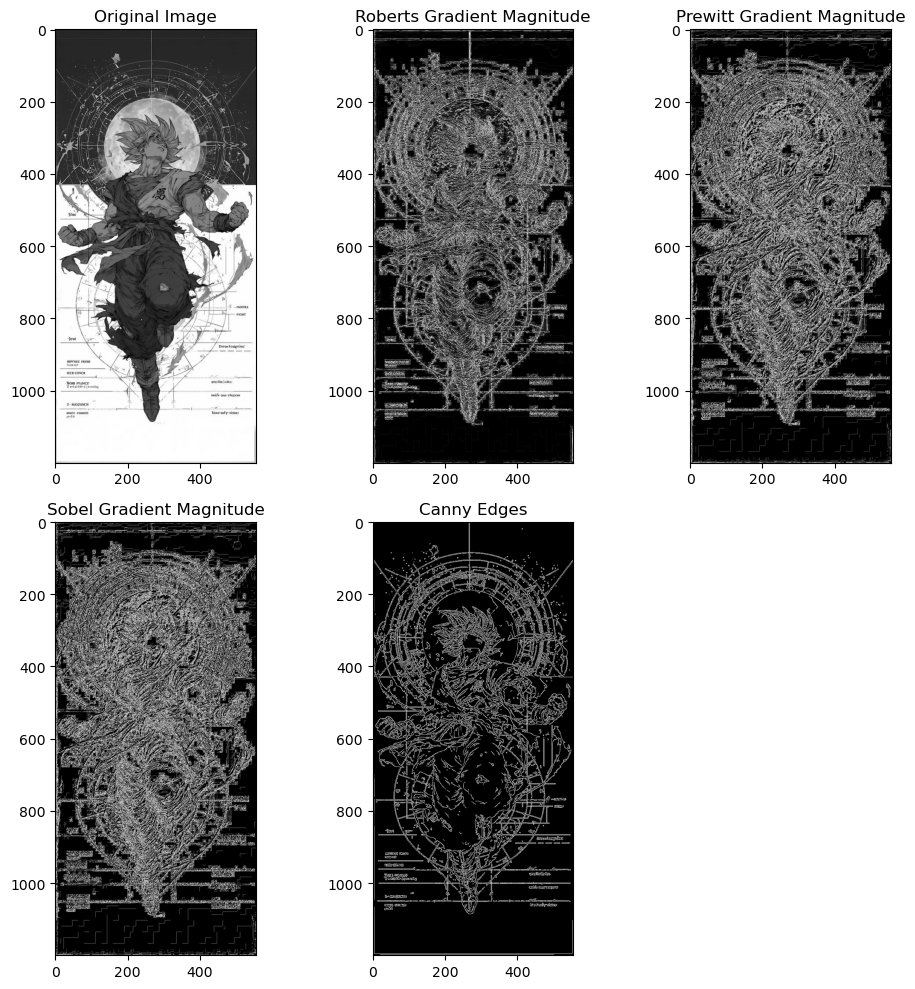

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('goku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Roberts
robertx = np.array([[-1, 0], [0, 1]])
roberty = np.array([[0, -1], [1, 0]])
robx_img = cv2.filter2D(gray, -1, robertx)   
roby_img = cv2.filter2D(gray, -1, roberty)  
rob_grad = np.sqrt(robx_img**2 + roby_img**2)
rob_grad_dir = np.arctan2(roby_img, robx_img)

# Prewitt
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
prex_img = cv2.filter2D(gray, -1, prewitt_x)
prey_img = cv2.filter2D(gray, -1, prewitt_y)
prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)
prewitt_dir = np.arctan2(prey_img, prex_img)

# Sobel
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
sobelx_img = cv2.filter2D(gray, -1, sobel_x)
sobely_img = cv2.filter2D(gray, -1, sobel_y)
sobel_mag = np.sqrt(sobelx_img**2 + sobely_img**2)
sobel_dir = np.arctan2(sobely_img, sobelx_img)

# Canny
canny_img = cv2.Canny(gray, 100, 200)   # ✅ umbral alto > umbral bajo (recomendado)

# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(2, 3, 1), plt.imshow(gray, cmap='gray'), plt.title('Original Image')
plt.subplot(2, 3, 2), plt.imshow(rob_grad, cmap='gray'), plt.title('Roberts Gradient Magnitude')
plt.subplot(2, 3, 3), plt.imshow(prewitt_mag, cmap='gray'), plt.title('Prewitt Gradient Magnitude')
plt.subplot(2, 3, 4), plt.imshow(sobel_mag, cmap='gray'), plt.title('Sobel Gradient Magnitude')
plt.subplot(2, 3, 5), plt.imshow(canny_img, cmap='gray'), plt.title('Canny Edges')
plt.tight_layout()
plt.show()